# Interbank contagion — where `infer` earns its place

Poledna (2023) calibrates six sectors but leaves **banks passive**: no interbank market, no
contagion, no deposit flight. This notebook adds that layer, and it is the one part of the model
that does not fit the ordinary tick.

Everything else in `skabm` is *replacement* dynamics — a rule reads this quarter's state and
overwrites it, once per tick, in a fixed order. Contagion is not like that. A distressed bank
makes its depositors flee, which distresses *their* other banks, which makes more depositors
flee, and the cascade has to run to a **fixed point** before the quarter is over. Expressed as
DELETE/INSERT upserts that means a sub-tick loop of hand-guessed depth.

`RDFSimulator(infer=...)` removes the guess: `Model.infer` evaluates recursive rules until
nothing new is derived, so one call per tick propagates distress across the whole graph however
deep it goes.

> `Model.infer` (Datalog / recursive CONSTRUCT) is a licensed maplib add-on — free for academic
> and personal use, but not in the PyPI wheels. This notebook is the only one that needs it.

In [1]:
import matplotlib.pyplot as plt
import polars as pl
import polars_random as pr

from skabm.behaviour.params import poledna_params
from skabm.simulation import RDFSimulator

N_FIRMS, N_HOUSEHOLDS, N_GOV, N_FOREIGN = 50, 500, 3, 10

pr.set_random_seed(0)
firms = (
    pl.DataFrame({
        "id": [f"firm_{i}" for i in range(N_FIRMS)],
        "size": pr.normal(100.0, 30.0, size=N_FIRMS).clip(10, None).round(0),
        "alpha": 1.0, "w_bar": 1.0, "tech_share": 0.1,
        "price": 1.0, "margin": 0.2, "liquidity": 0.0,
    })
    .with_columns(pl.col("size").cast(pl.Float64))
    .with_columns(output=pl.col("size") * pl.col("alpha") * 0.9)
    .with_columns(profit=0.2 * pl.col("output"))
)

pr.set_random_seed(1)
households = pl.DataFrame({
    "id": [f"hh_{i}" for i in range(N_HOUSEHOLDS)],
    "psi": 0.9,
    "income": (pr.uniform(0.5, 2.0, size=N_HOUSEHOLDS) * 10.0).round(2),
})

governments = pl.DataFrame({
    "id": [f"gov_{i}" for i in range(N_GOV)],
    "budget": [50.0] * N_GOV, "tax_rate": 0.2134,
})
foreign_firms = pl.DataFrame({
    "id": [f"foreign_{i}" for i in range(N_FOREIGN)], "demand_size": [20.0] * N_FOREIGN,
})
central_bank = pl.DataFrame({
    "id": ["central_bank"], "policy_rate": [0.009], "inflation_target": [0.005],
    "prev_output": [float(firms["output"].sum())], "prev_price": [1.0],
})

populations = dict(
    Firm=firms, Household=households, Government=governments,
    ForeignFirm=foreign_firms, CentralBank=central_bank,
)

params = {
    **poledna_params,
    "total_deposits": 2000.0,
    "firm_ownership_ratio": N_FIRMS / N_HOUSEHOLDS,
    # Expectations are learned from the model's own history, not parameterised.
    # A cold run starts with an empty history, so the opening forecast is zero
    # and a fully deterministic economy would sit still; the shocks below are
    # what give the AR(1) something to estimate.  See 03_sac_learning.ipynb.
    "growth_sigma": 0.02,
    "inflation_sigma": 0.01,
}
banks = pl.DataFrame({
    "id": [f"bank_{i}" for i in range(5)],
    # bank_0 opens below the distress threshold and seeds the cascade
    "capital_ratio": [0.02, 0.10, 0.09, 0.08, 0.07],
    "leverage": [12.0] * 5,
    "deposit_share": [0.20, 0.25, 0.20, 0.20, 0.15],
})
populations["Bank"] = banks
params |= {"distress_threshold": 0.03, "flee_amount_threshold": 5.0}
banks

id,capital_ratio,leverage,deposit_share
str,f64,f64,f64
"""bank_0""",0.02,12.0,0.2
"""bank_1""",0.1,12.0,0.25
"""bank_2""",0.09,12.0,0.2
"""bank_3""",0.08,12.0,0.2
"""bank_4""",0.07,12.0,0.15


## Three additions to the base rule set

| rule | kind | what it does |
|---|---|---|
| `bank_depositors` | init CONSTRUCT | assigns each household and firm to a bank, weighted by `def:deposit_share` |
| `bank_capital` | update | capital ratio responds to deposit outflows each tick |
| `interbank_contagion` | **infer** | distress propagates through the depositor network to a fixed point |

Only the third is recursive. The other two are ordinary rules, and the non-banking rules are
untouched — this is an extension, not a fork.

In [2]:
from skabm.behaviour.bank import bank_capital, bank_depositors, interbank_contagion
from skabm.behaviour.firm import firm_ownership, firm_price, firm_produce, firm_sales
from skabm.behaviour.household import (
    household_income, household_income_init, household_wealth_init, satisificing_consume,
)
from skabm.behaviour.macro import centralbank_rate, government_spend

sim = RDFSimulator(
    init_rules=(firm_ownership, household_income_init, household_wealth_init, bank_depositors),
    update_rules=(
        firm_produce, firm_price, household_income, satisificing_consume,
        firm_sales, government_spend, centralbank_rate, bank_capital,
    ),
    infer=interbank_contagion,   # <- the fixed-point layer
    params=params,
    n_periods=8,
    random_seed=0,
)
print(interbank_contagion[0] if isinstance(interbank_contagion, (list, tuple)) else interbank_contagion)

PREFIX ex: <http://example.net/skabm#>PREFIX def: <urn:maplib_default:>CONSTRUCT { ?b ex:is_distressed true } WHERE { ?b a ex:Bank ; def:capital_ratio ?cr . FILTER(?cr < 0.03) . }


## Run, watching the cascade spread

In [3]:
DISTRESSED = """
PREFIX ex: <http://example.net/skabm#>
SELECT ?b WHERE { ?b ex:is_distressed true }
"""
RATIOS = """
PREFIX ex: <http://example.net/skabm#>
PREFIX def: <urn:maplib_default:>
SELECT ?b ?cr WHERE { ?b a ex:Bank ; def:capital_ratio ?cr } ORDER BY ?b
"""

rows = []
for t, state in enumerate(sim.fit_iter(**populations)):
    distressed = sim.model_.query(DISTRESSED)["b"].to_list()
    ratios = sim.model_.query(RATIOS)
    active = state.drop_nulls("output")
    rows.append({
        "t": t,
        "gdp": (active["price"] * active["output"] * (1 - active["tech_share"])).sum(),
        "distressed": len(distressed),
        **{iri.rsplit("_", 1)[-1].rstrip(">"): cr
           for iri, cr in zip(ratios["b"], ratios["cr"])},
    })

contagion_path = pl.DataFrame(rows)
contagion_path

t,gdp,distressed,0,1,2,3,4
i64,f64,i64,f64,f64,f64,f64,f64
0,4159.560315,5,0.02,0.1,0.09,0.08,0.07
1,4135.395418,5,-0.04429,0.068603,0.067001,0.054675,0.05554
2,4122.729684,5,-0.108579,0.037206,0.044001,0.02935,0.04108
3,4077.151743,5,-0.172869,0.005809,0.021002,0.004026,0.02662
4,4056.35184,5,-0.237158,-0.025588,-0.001998,-0.021299,0.01216
5,4035.787598,5,-0.301448,-0.056986,-0.024997,-0.046624,-0.0023
6,4020.820499,5,-0.365737,-0.088383,-0.047997,-0.071949,-0.01676
7,4001.632644,5,-0.430027,-0.11978,-0.070996,-0.097274,-0.03122


## What spread, and to whom

`def:flees_to` / `def:flees_amount` are written by the inference itself — the deposit flight is a
derived fact, not something a tick loop bookkept.

In [4]:
flight = sim.model_.query("""
PREFIX ex: <http://example.net/skabm#>
PREFIX def: <urn:maplib_default:>
SELECT ?agent ?to ?amount WHERE {
    ?agent def:flees_to ?to ; def:flees_amount ?amount .
}
ORDER BY DESC(?amount)
""")
print(f"{flight.height} flight events")
flight.head(10)

1400 flight events


agent,to,amount
str,str,f64
"""<http://example.net/skabm#hh_3…","""<http://example.net/skabm#bank…",9.133524
"""<http://example.net/skabm#hh_3…","""<http://example.net/skabm#bank…",9.133524
"""<http://example.net/skabm#hh_3…","""<http://example.net/skabm#bank…",9.133524
"""<http://example.net/skabm#hh_3…","""<http://example.net/skabm#bank…",9.133524
"""<http://example.net/skabm#hh_3…","""<http://example.net/skabm#bank…",8.948646
"""<http://example.net/skabm#hh_3…","""<http://example.net/skabm#bank…",8.948646
"""<http://example.net/skabm#hh_3…","""<http://example.net/skabm#bank…",8.948646
"""<http://example.net/skabm#hh_3…","""<http://example.net/skabm#bank…",8.948646
"""<http://example.net/skabm#hh_3…","""<http://example.net/skabm#bank…",8.897939


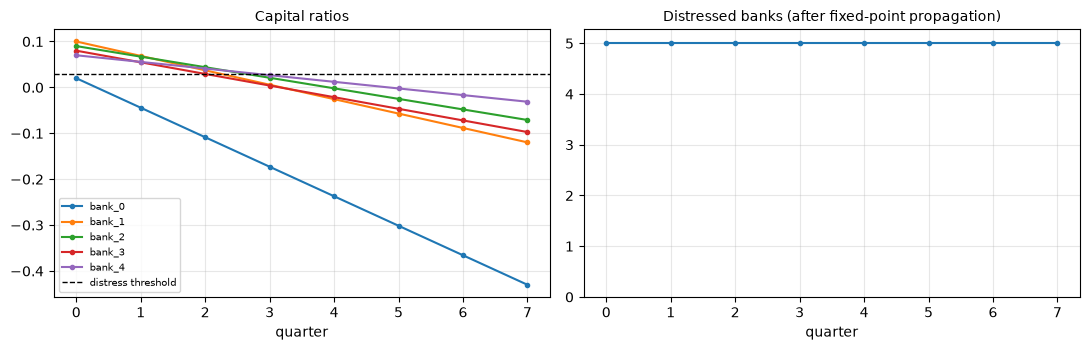

In [5]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.6))
for col in [c for c in contagion_path.columns if c.isdigit()]:
    left.plot(contagion_path["t"], contagion_path[col], marker="o", ms=3, label=f"bank_{col}")
left.axhline(params["distress_threshold"], ls="--", c="k", lw=1, label="distress threshold")
left.set_title("Capital ratios", fontsize=10); left.set_xlabel("quarter")
left.legend(fontsize=7); left.grid(alpha=0.3)

right.step(contagion_path["t"], contagion_path["distressed"], where="mid", marker="o", ms=3)
right.set_title("Distressed banks (after fixed-point propagation)", fontsize=10)
right.set_xlabel("quarter"); right.set_ylim(bottom=0); right.grid(alpha=0.3)
fig.tight_layout()

## The point

The tick loop never changed. `RDFSimulator` runs the update rules, then calls `infer` once, then
yields — so the depth of the cascade is a property of the *rule*, not of the engine or of a
hand-tuned loop bound. Replacement dynamics stay SPARQL upserts, because they are not recursive
and gain nothing from a fixed point; only the propagation layer uses Datalog.